In [ ]:
%%capture
!pip install fredapi
!pip install yfinance
!pip install yahoo_fin
#Here we also analyze Options, although they are not lending securities
# (it is a zero-sum game typically and a direct one.) but u can borrow money or be on margin to sell or buy options
#1-Get data
#2-Clean
#3-overview and calculate metrics of importance relative to previous project
#4-visualize
# Analyze in correlation, causality, and volatility
# Maybe greeks calculations
# Conclude

In [ ]:
from fredapi import Fred as fd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from datetime import date
from datetime import datetime as dt
from yahoo_fin import options
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
fred = fd(api_key='Useurkey')

# Scenario 1: Credit cards



> We will analyze some credit cards datasets to see how credit cards loan and usage are affected by the economic and banks' policy



In [ ]:
# Let's download data of credit cards balance utilization
cc_total_balances = fred.get_series('RCCCBBALTOT', observation_start='2012-07-01', observation_end='2024-01-01')
cc_utilization_50 = fred.get_series('RCCCBACTIVEUTILPCT50', observation_start='2012-07-01', observation_end='2024-01-01')
cc_utilization_75 = fred.get_series('RCCCBACTIVEUTILPCT75', observation_start='2012-07-01', observation_end='2024-01-01')
cc_utilization_90 = fred.get_series('RCCCBACTIVEUTILPCT90', observation_start='2012-07-01', observation_end='2024-01-01')

In [ ]:
cc_utilization_50.describe()

,0
count,47.000000
mean,8.122128
std,1.475887
min,4.970000
25%,7.275000
50%,8.000000
75%,9.185000
max,11.130000


> Half of the credit card users (50 percentile) only use about 8% of their card limit. Which means the leverage in credit card limit is too high for most consumers.


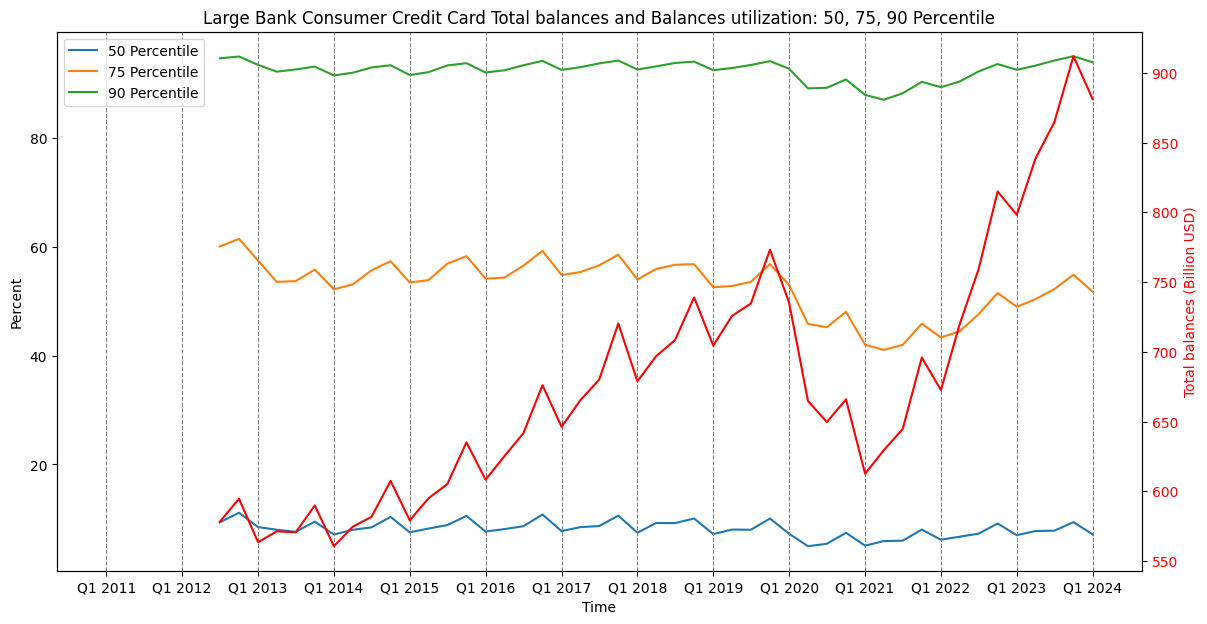

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(cc_utilization_50.index, cc_utilization_50.values, label='50 Percentile')
ax.plot(cc_utilization_75.index, cc_utilization_75.values, label='75 Percentile')
ax.plot(cc_utilization_90.index, cc_utilization_90.values, label='90 Percentile')
ax.set_xlabel('Time')
ax.set_ylabel('Percent')

ax2 = ax.twinx()
ax2.plot(cc_total_balances.index, cc_total_balances.values, color='r', label='Total balances')
ax2.set_ylabel('Total balances (Billion USD)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax.xaxis.set_major_locator(mdates.YearLocator(month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('Q1 %Y'))

for tick in ax.get_xticks():
    ax.axvline(x=tick, color='gray', linestyle='--', linewidth=0.8)

ax.set_title('Large Bank Consumer Credit Card Total balances and Balances utilization: 50, 75, 90 Percentile')
ax.legend(loc='upper left')

> We can see that there is a clear pattern of credit card balance and usage that drop in the first quarter then grow and peak in the 4th quarter

> Credit card total balance shows a clear growing trend since 2012, but drop since 2020, when there is a recession in the US, but quickly bounce back and grow up until now

> During the recession, credit card utilization drops, especially for heavy-usage consumers, as leverage is minimized during economic hardship

In [ ]:
# Let's download data of credit cards with 30 or more days past due
cc_past_due = fred.get_series('RCCCBBALDPD30P', observation_start='2012-07-01', observation_end='2024-01-01')

Text(0.5, 1.0, 'Credit Card: 30 or More Days Past Due Rates vs Total Balance')

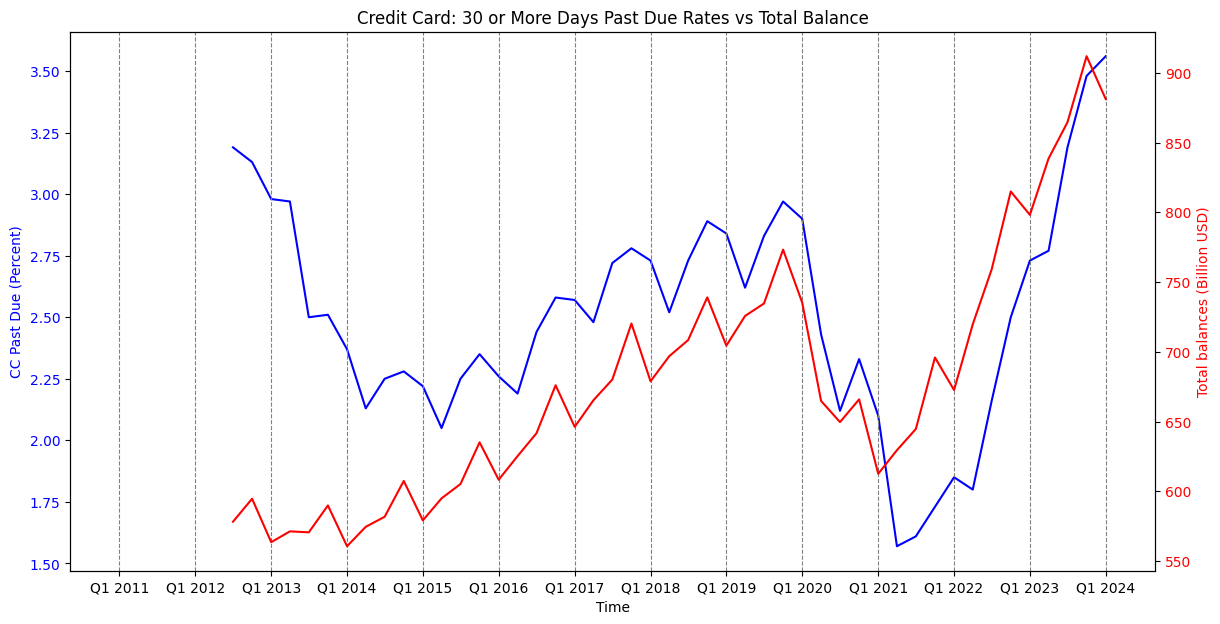

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(cc_past_due.index, cc_past_due.values, color='b', label='CC Past Due (Percent)')
ax.set_xlabel('Time')
ax.set_ylabel('CC Past Due (Percent)', color='b')
ax.tick_params(axis='y', labelcolor='b')

ax2 = ax.twinx()
ax2.plot(cc_total_balances.index, cc_total_balances.values, color='r', label='Total balances')
ax2.set_ylabel('Total balances (Billion USD)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax.xaxis.set_major_locator(mdates.YearLocator(month=1, day=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('Q1 %Y'))
for tick in ax.get_xticks():
    ax.axvline(x=tick, color='gray', linestyle='--', linewidth=0.8)

ax.set_title('Credit Card: 30 or More Days Past Due Rates vs Total Balance')

> We can also see a similar pattern and high correlation between credit card total balance and past due rates. Take into account the change in card usage throughout the year, we can see that high utilization of leverage leads to high rate of miss payments.

In [ ]:
# Let's download data of banks tightening standards for credit card loans
tight_cc_loan = fred.get_series('DRTSCLCC')

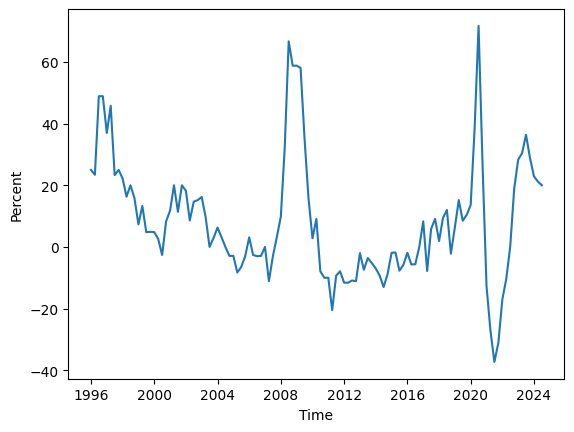

In [ ]:
fig, ax = plt.subplots()
ax.plot(tight_cc_loan.index, tight_cc_loan.values)
ax.set_xlabel('Time')
ax.set_ylabel('Percent')
ax.set_label('Net Percentage of Domestic Banks Tightening Standards for Credit Card Loans')

> During recession (2008 and 2020), banks have to tighten their credit card loan standards, which demonstrate the leverage and liquidity risks of credit cards



# Scenario 2: Mortgages

In [ ]:
# Let's download data of mortgages loan-to-value ratio
mortage_ltv_50 = fred.get_series('RCMFLOLTVPCT50', observation_start='2012-07-01', observation_end='2024-01-01')
mortage_ltv_75 = fred.get_series('RCMFLOLTVPCT75', observation_start='2012-07-01', observation_end='2024-01-01')
mortage_ltv_90 = fred.get_series('RCMFLOLTVPCT90', observation_start='2012-07-01', observation_end='2024-01-01')

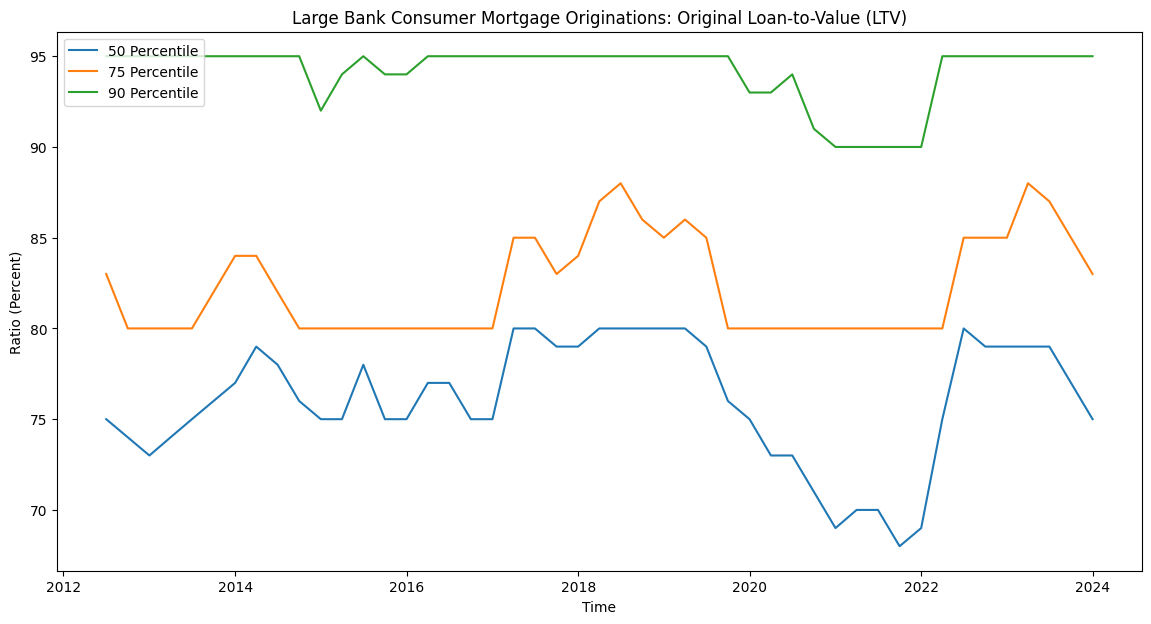

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(mortage_ltv_50.index, mortage_ltv_50.values, label='50 Percentile')
ax.plot(mortage_ltv_75.index, mortage_ltv_75.values, label='75 Percentile')
ax.plot(mortage_ltv_90.index, mortage_ltv_90.values, label='90 Percentile')
ax.set_xlabel('Time')
ax.set_ylabel('Ratio (Percent)')
ax.set_title('Large Bank Consumer Mortgage Originations: Original Loan-to-Value (LTV)')
ax.legend(loc='upper left')

> We can see that mortgages are highly leveraged loans. Loan-to-Value ratio is normally 75% to 85% and can reach as high as 95%, which means borrowers only need to pay a 5% downpayment to own the asset.

> During the US recession from 2020 - 2022, the LTV ratio for half of the mortgages dropped to a minimum of 65%. This is due to the limit of credit due to an economic downside, which demonstrates the liquidity aspect of mortgages.


In [ ]:
# Let's download and graph data of banks tightening standards for Subprime Mortgage Loans
tight_mortgage = fred.get_series('DRTSSP', observation_start='2007-04-01', observation_end='2024-07-01')



Text(0.5, 1.0, 'Net Percentage of Domestic Banks Tightening Standards for Subprime Mortgage Loans')

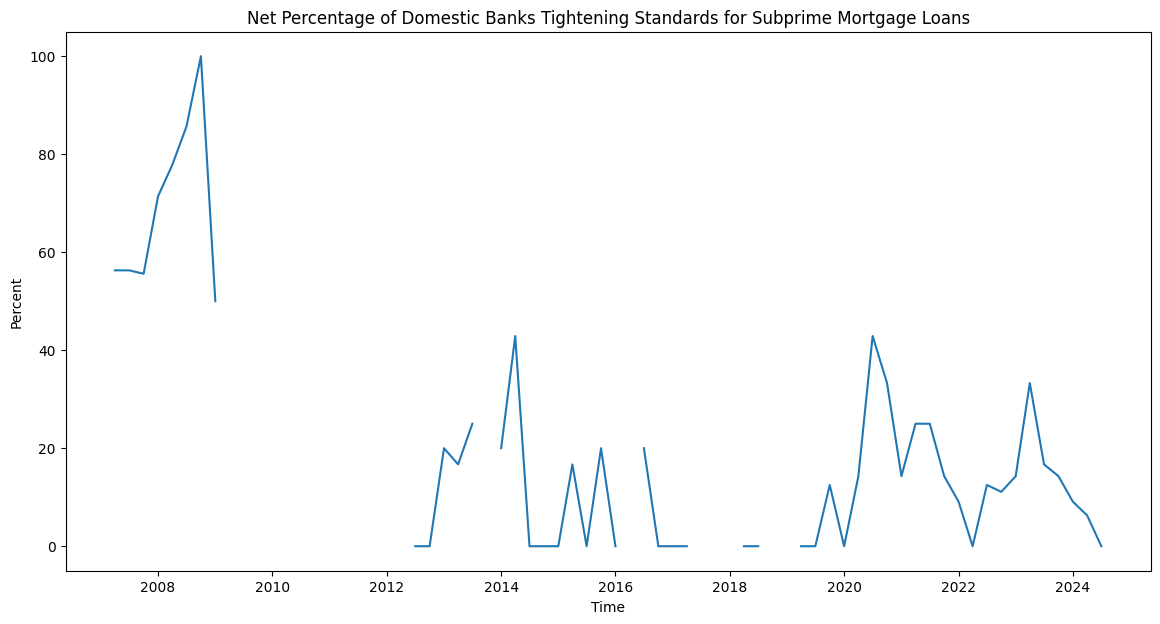

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(tight_mortgage.index, tight_mortgage.values)
ax.set_xlabel('Time')
ax.set_ylabel('Percent')
ax.set_title('Net Percentage of Domestic Banks Tightening Standards for Subprime Mortgage Loans')

> We can observe the tightening standards for mortgages in all domestic banks in Q4 2008, after the great financial crisis caused by predatory lending of subprime mortgages.


# Scenario 3: Money at a fixed rate for a business for a construction loan.


# Scenario 4: Equity


#This time we will study the volatility of the stock using a different measure of volatility
# We will use on the spot volatility using ATR with a period of 1, i.e. True Range
# We then compare it to the volume of the day and see the correlation.
# We can also check for self-exciting behavior and if there is some auto-correlation
# We filter data based on extreme returns to find an interesting correlation

In [ ]:
# We get the stock data directly from yahoo finance as it is easy and provides enough to analyze.
df=yf.download('AAPL',period='5y', interval='1d')# we will use AAPL
df.isna().sum() #1-Get data [check]
#Clean[check]

[*********************100%***********************]  1 of 1 completed


,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Data seems complete with no gaps. Maybe we need to check for outliers

In [ ]:
df.describe() #initial view[check]

,Open,High,Low,Close,Adj Close,Volume
count,1259.000000,1259.000000,1259.000000,1259.000000,1259.000000,1.259000e+03
mean,145.864599,147.494285,144.340447,145.995215,144.298361,9.326153e+07
std,41.405198,41.654201,41.120082,41.392140,41.892882,5.266783e+07
min,56.455002,56.947498,53.152500,56.092499,54.284832,2.246027e+07
25%,123.960003,125.294998,122.250000,124.325001,121.564144,5.882020e+07
50%,148.949997,150.399994,147.509995,149.100006,147.018097,7.926520e+07
75%,174.084999,175.995003,172.575005,174.584999,172.870277,1.102086e+08
max,236.479996,237.229996,233.089996,234.820007,234.548523,4.265100e+08


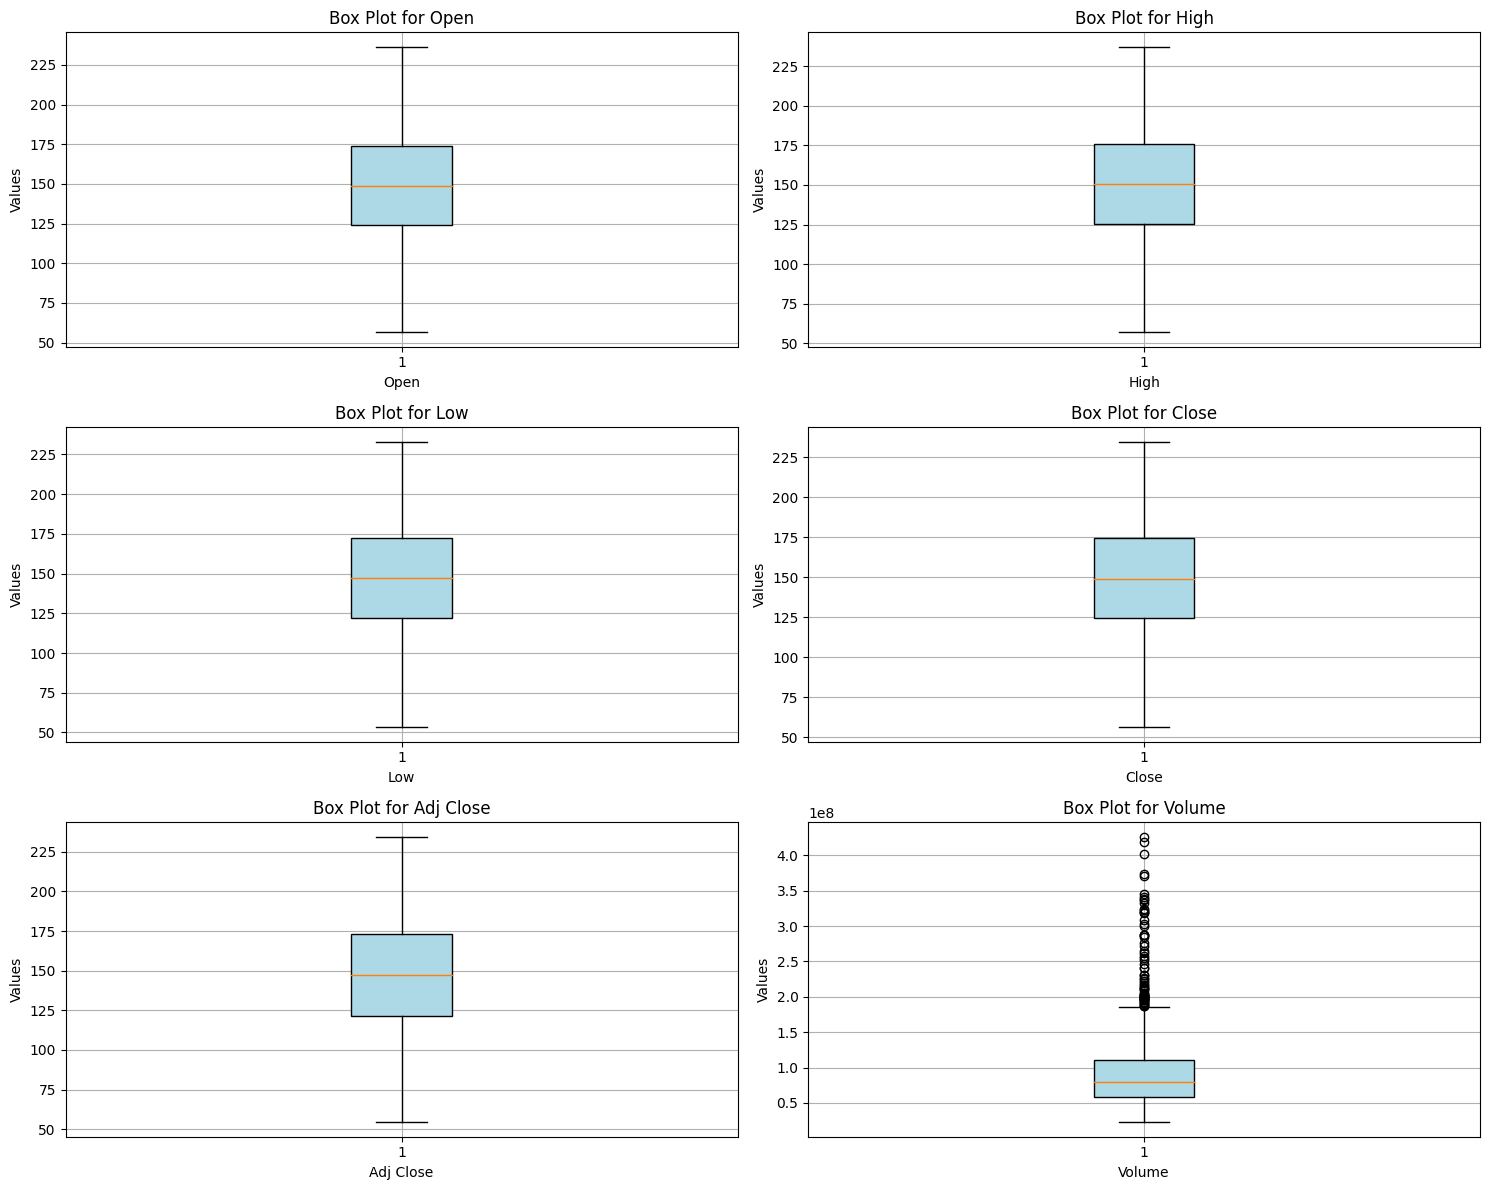

In [ ]:
#initial visual check [Check]
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Values')
    axes[i].grid(True)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


We see that the volume data has a lot of extreme values. We will analyze True range and the volume size in the project. On the other hand the price data does not show extremes in the daily data in the box plot graph case, we can do an alaysis oveer the returns.

In [ ]:
df['ret']=df['Adj Close'].pct_change()
df['ret']=df['ret'].fillna(0) #data manipulation to get more features and cleaning [Check]


In [ ]:
df

,Open,High,Low,Close,Adj Close,Volume,ret
Date,,,,,,,
2019-10-07,56.567501,57.482498,56.459999,56.764999,54.928314,122306000,0.000000
2019-10-08,56.455002,57.014999,56.082500,56.099998,54.284832,111820000,-0.011715
2019-10-09,56.757500,56.947498,56.410000,56.757500,54.921051,74770400,0.011720
2019-10-10,56.982498,57.610001,56.825001,57.522499,55.661301,113013600,0.013478
2019-10-11,58.237499,59.410000,58.077499,59.052502,57.141788,166795600,0.026598
...,...,...,...,...,...,...,...
2024-10-01,229.520004,229.649994,223.740005,226.210007,226.210007,63285000,-0.029142
2024-10-02,225.889999,227.369995,223.020004,226.779999,226.779999,32880600,0.002520
2024-10-03,225.139999,226.809998,223.320007,225.669998,225.669998,34044200,-0.004895


{'whiskers': [<matplotlib.lines.Line2D at 0x7c741dc09810>,
 'caps': [<matplotlib.lines.Line2D at 0x7c741dc099c0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7c741dc0a2c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7c741dc0ac20>],
 'fliers': [<matplotlib.lines.Line2D at 0x7c741dc08610>],
 'means': []}

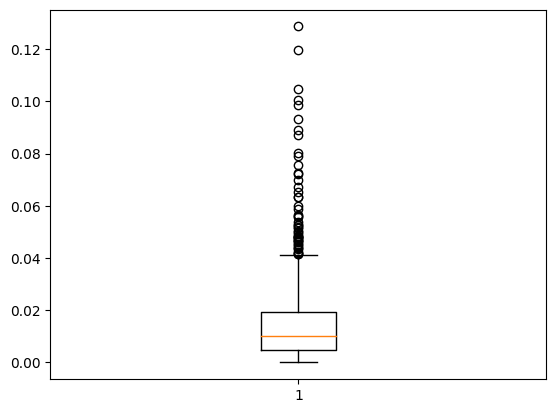

In [ ]:
plt.boxplot(df['ret'].abs()) #checking the new feature [check]


We see that the returns also show a lot of extremes when taking the absolute value (even without the absolute value) which is proof of fat tails to a degree.

In [ ]:
#True range =tr
df['tr'] = (df[['High', 'Low', 'Adj Close']]
                    .apply(lambda x: max(x['High'] - x['Low'],
                    abs(x['High']- x['Adj Close']),
                    abs(x['Low'] - x['Adj Close'])), axis=1))


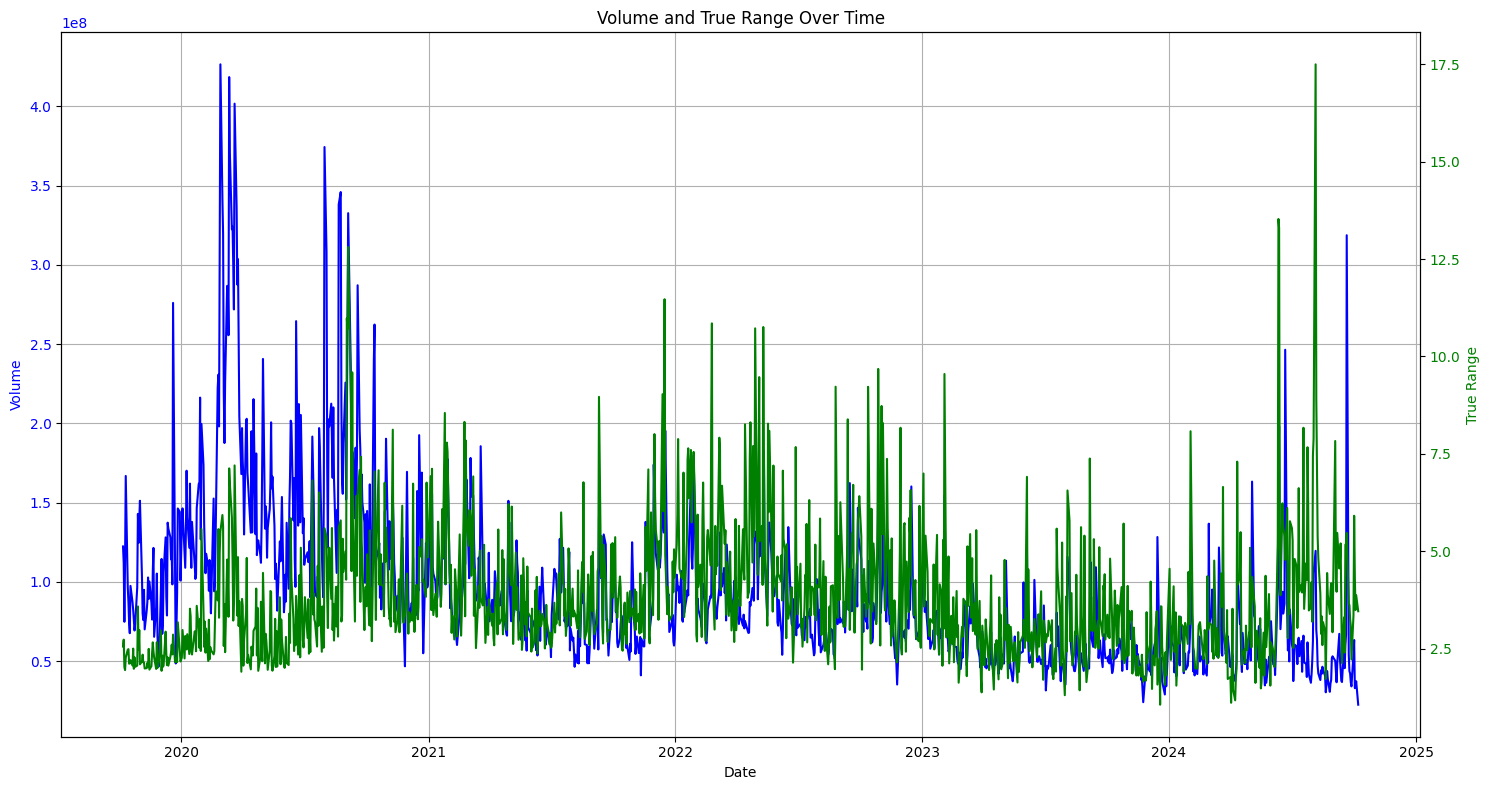

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(df.index, df['Volume'], color='blue', label='Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(df.index, df['tr'], color='green', label='True Range')
ax2.set_ylabel('True Range', color='green')
ax2.tick_params(axis='y', labelcolor='green')
plt.title('Volume and True Range Over Time')
ax1.grid(True)
plt.tight_layout()
plt.show()

we can see a graph of the volume and true range (a measure of volatility over time. just from the graph we can guess some sort of correlation. Maybe if we filter data into extremes and regular retrurns (Exclude rows with the top 1% percent of the absolute returns)

In [ ]:
#correlation and auto_correlation, pearson is automatic
df['Volume'].corr(df['tr'])

0.36105395216297276

<Figure size 1000x600 with 0 Axes>

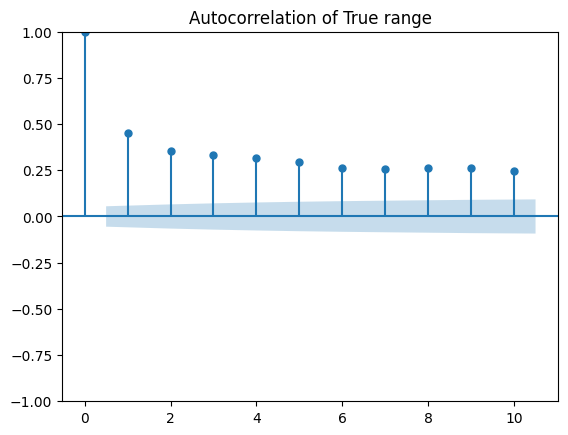

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10, 6))
plot_acf(df['tr'].dropna(), lags=10)  # Adjust lags if needed but it seems stable
ax.set_xlabel('Lags')
ax.set_ylabel('Correlation')
plt.title('Autocorrelation of True range')
plt.show()

we see that the true range has a natural autocorrelation between0.50 and 0.25 about immediately after the first value. Hence we would assume it is not really important. this continues with longer lags indicating similar change in general.

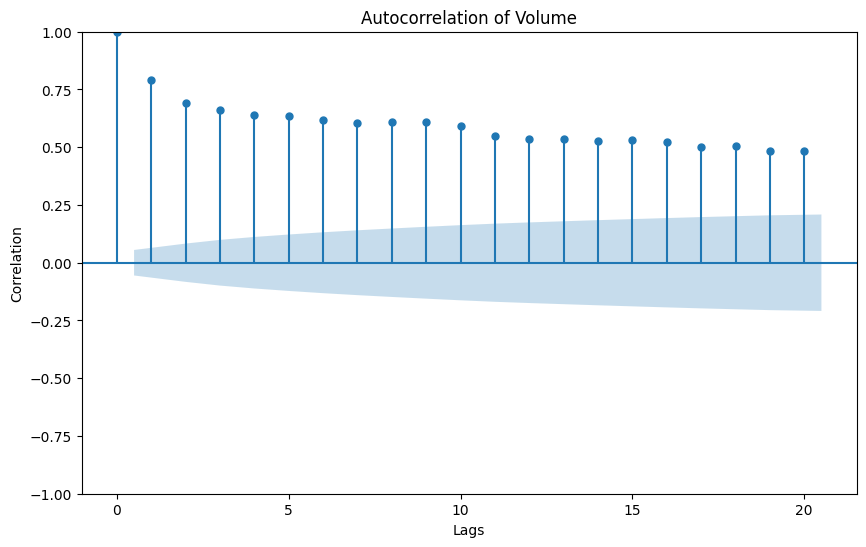

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
plot_acf(df['Volume'], lags=20, ax=ax)  # Adjust lags as needed
ax.set_xlabel('Lags')
ax.set_ylabel('Correlation')
ax.set_title('Autocorrelation of Volume')
plt.show()

Generally the volume is better autocorrelated than volatility in the next day, we see that yesterday's volume is highly corrrelated(above 50%) to today's volume at least in a 20-days cycle.

In [ ]:
df['abs_ret']=df['ret'].abs() #segmentation by the return data the "new" feature

topdf=df[df['abs_ret']>=df['abs_ret'].quantile(0.99)]
bottomdf=df[df['abs_ret']<df['abs_ret'].quantile(0.99)]

In [ ]:
#repeat the analysis above but after seperation
topdf['Volume'].corr(topdf['tr'])
#We see that in extreme values, negative correlation between true range and Volume
#This proves our previous work that extremes, is associated with drying up liquidity

-0.3673045526786961

In [ ]:
bottomdf['Volume'].corr(bottomdf['tr'])
#while there is a similar low correlation between tr and volume in the lower return range

0.3458140744111788

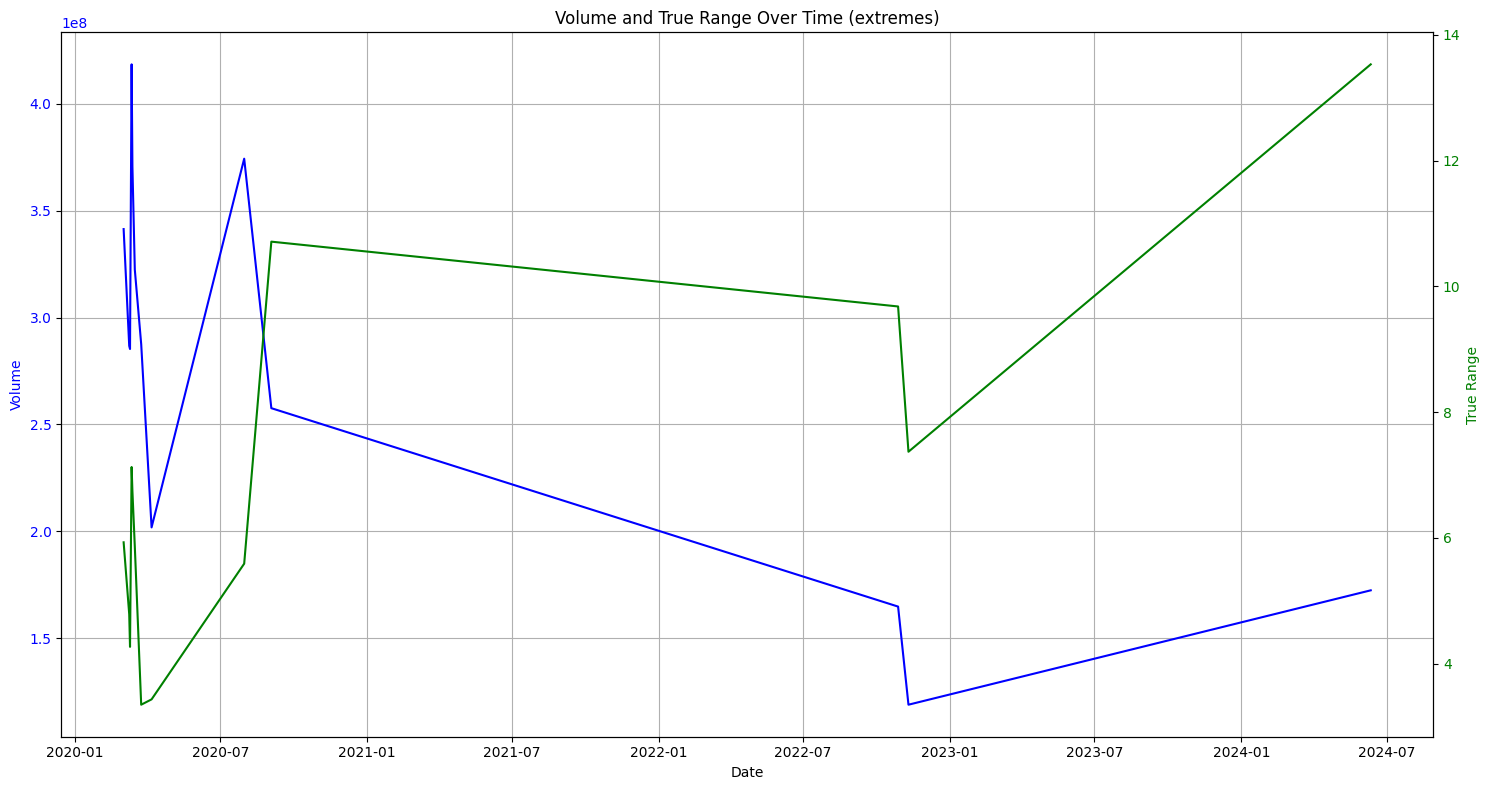

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 8))
ax1.plot(topdf.index, topdf['Volume'], color='blue', label='Volume')
ax1.set_xlabel('Date')
ax1.set_ylabel('Volume', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax2 = ax1.twinx()
ax2.plot(topdf.index, topdf['tr'], color='green', label='True Range')
ax2.set_ylabel('True Range', color='green')
ax2.tick_params(axis='y', labelcolor='green')
plt.title('Volume and True Range Over Time (extremes)')
ax1.grid(True)
plt.tight_layout()
plt.show()

While they may look the same, but they do diverge from eachother. Hence, more ways to say (crashes deplete volatility)

# Scenario 5: Lending Bonds

# Scenario 6: illiquid security (Options)


In [ ]:
#Here we also analyze Options, although they are not lending securities
# (it is a zero-sum game typically and a direct one.) but u can borrow money or be on margin to sell or buy options
#1-Get data [kinda check, historical data requires money so we will just use the available data]
#2-Clean [check]
#3-overview and calculate metrics of importance relative to previous project
#4-visualize
# Analyze in correlation, causality, and volatility
# Maybe greeks calculations
# Conclude

In [ ]:
#First we repeat the previous work
ticker = "AAPL"
stock = yf.Ticker(ticker)
expiration_dates = stock.options

In [ ]:
vix = yf.download("^VIX", period="3mo", interval="1d")
aapl = yf.download('aapl', period="3mo", interval="1d")
aapl['ret'] = aapl['Adj Close'].pct_change() * 100
vix['ret'] = vix['Adj Close'].pct_change() * 100

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
chosen_expiration = expiration_dates


# Fetch the option chain for the chosen expiration date (for example the first upcoming expiration we can find in yfinance)
option_chain = stock.option_chain()

# Separate calls and puts
calls = option_chain.calls
puts = option_chain.puts
option_chain

Options(calls=         contractSymbol             lastTradeDate  strike  lastPrice     bid  \
0   AAPL241011C00100000 2024-10-04 19:32:40+00:00   100.0     124.05  122.50   
1   AAPL241011C00120000 2024-10-03 16:09:18+00:00   120.0     105.50  102.65   
2   AAPL241011C00135000 2024-10-03 19:50:24+00:00   135.0      90.24   87.65   
3   AAPL241011C00140000 2024-10-07 18:35:41+00:00   140.0      83.11   82.65   
4   AAPL241011C00145000 2024-10-07 14:54:24+00:00   145.0      80.25   77.65   
5   AAPL241011C00150000 2024-10-07 18:56:21+00:00   150.0      72.55   72.60   
6   AAPL241011C00160000 2024-10-04 16:06:40+00:00   160.0      65.45   62.60   
7   AAPL241011C00165000 2024-10-07 14:16:24+00:00   165.0      60.20   57.60   
8   AAPL241011C00170000 2024-10-04 19:49:54+00:00   170.0      56.46   52.75   
9   AAPL241011C00175000 2024-10-07 18:00:09+00:00   175.0      49.04   47.85   
10  AAPL241011C00180000 2024-10-07 16:27:17+00:00   180.0      44.78   42.75   
11  AAPL241011C00185000 20

In [ ]:
expiration_dates

('2024-10-11',
 '2024-10-18',
 '2024-10-25',
 '2024-11-01',
 '2024-11-08',
 '2024-11-15',
 '2024-11-22',
 '2024-12-20',
 '2025-01-17',
 '2025-02-21',
 '2025-03-21',
 '2025-04-17',
 '2025-06-20',
 '2025-08-15',
 '2025-09-19',
 '2025-12-19',
 '2026-01-16',
 '2026-06-18',
 '2026-12-18',
 '2027-01-15')

In [ ]:
puts['volume']=puts['volume'].fillna(0)
cur_price = yf.download('aapl',period='1y', interval='1d').tail(1)['Close'].to_numpy()[0]

#puts=puts[(puts["strike"] > cur_price * 1.05) & (puts["strike"] < cur_price * 0.95)]

calls['volume']=calls['volume'].fillna(0)

#calls=calls[(calls["strike"] > cur_price * 1.1) & (calls["strike"] < cur_price * 0.9)]
puts

[*********************100%***********************]  1 of 1 completed


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL241011P00100000,2024-10-01 14:16:10+00:00,100.0,0.01,0.00,0.01,0.000000,0.000000,5.0,8,2.062505,False,REGULAR,USD
1,AAPL241011P00105000,2024-10-01 13:45:20+00:00,105.0,0.12,0.00,0.08,0.000000,0.000000,0.0,1,2.343754,False,REGULAR,USD
2,AAPL241011P00110000,2024-09-26 16:50:53+00:00,110.0,0.01,0.00,0.08,0.000000,0.000000,0.0,1,2.210942,False,REGULAR,USD
3,AAPL241011P00120000,2024-10-01 17:57:59+00:00,120.0,0.02,0.00,0.08,0.000000,0.000000,0.0,1,1.953125,False,REGULAR,USD
4,AAPL241011P00125000,2024-10-07 13:50:16+00:00,125.0,0.08,0.00,0.03,0.070000,700.000100,10.0,1,1.671877,False,REGULAR,USD
5,AAPL241011P00130000,2024-09-11 18:27:04+00:00,130.0,0.02,0.00,0.01,0.000000,0.000000,0.0,50,1.437503,False,REGULAR,USD
6,AAPL241011P00135000,2024-09-18 14:44:29+00:00,135.0,0.01,0.00,0.08,0.000000,0.000000,1250.0,1,1.609377,False,REGULAR,USD
7,AAPL241011P00140000,2024-10-04 13:48:13+00:00,140.0,0.01,0.00,0.08,0.000000,0.000000,1.0,2,1.500002,False,REGULAR,USD
8,AAPL241011P00145000,2024-09-19 15:09:47+00:00,145.0,0.02,0.00,0.08,0.000000,0.000000,31.0,41,1.394534,False,REGULAR,USD
9,AAPL241011P00150000,2024-10-03 19:24:01+00:00,150.0,0.01,0.00,0.03,0.000000,0.000000,20.0,235,1.171879,False,REGULAR,USD


In [ ]:

#This time we analyze the liquidity using VIX, spread, implied volatility, and PC ratios


# References

1. Federal Reserve Bank of Philadelphia, Large Bank Consumer Credit Card Balances: Total Balances [RCCCBBALTOT], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCCCBBALTOT, October 4, 2024.
2. Federal Reserve Bank of Philadelphia, Large Bank Consumer Credit Card Balances: Utilization: Active Accounts Only: 50th Percentile [RCCCBACTIVEUTILPCT50], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCCCBACTIVEUTILPCT50, October 4, 2024.
3. Federal Reserve Bank of Philadelphia, Large Bank Consumer Credit Card Balances: Utilization: Active Accounts Only: 75th Percentile [RCCCBACTIVEUTILPCT75], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCCCBACTIVEUTILPCT75, October 4, 2024.
4. Federal Reserve Bank of Philadelphia, Large Bank Consumer Credit Card Balances: Utilization: Active Accounts Only: 90th Percentile [RCCCBACTIVEUTILPCT90], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCCCBACTIVEUTILPCT90, October 4, 2024.
5. Board of Governors of the Federal Reserve System (US), Net Percentage of Domestic Banks Tightening Standards for Credit Card Loans [DRTSCLCC], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DRTSCLCC, October 4, 2024.
6. Federal Reserve Bank of Philadelphia, Large Bank Consumer Mortgage Originations: Original Loan-to-Value (LTV): 50th Percentile [RCMFLOLTVPCT50], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCMFLOLTVPCT50, October 4, 2024.
7. Federal Reserve Bank of Philadelphia, Large Bank Consumer Mortgage Originations: Original Loan-to-Value (LTV): 75th Percentile [RCMFLOLTVPCT75], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCMFLOLTVPCT75, October 4, 2024.
8. Federal Reserve Bank of Philadelphia, Large Bank Consumer Mortgage Originations: Original Loan-to-Value (LTV): 90th Percentile [RCMFLOLTVPCT90], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RCMFLOLTVPCT90, October 4, 2024.
9. Apple Inc. (AAPL) Stock Price, News, Quote & History. Yahoo Finance, https://finance.yahoo.com/quote/AAPL/. Accessed 7 Oct. 2024.
10. Yahoo Finance, Apple Options maturity Oct 7, https://finance.yahoo.com/quote/AAPL/options/?date=1727395200, September 26, 2024